# Insurance Fraud Detection

## 1. Project goal
The goal of this project is to build a machine learning model that predicts whether an insurance claim is fraudulent or not.

The dataset contains information about customers, insurance policies, incidents, claim amounts, vehicles, and fraud reports. The target variable is fraud_reported, which was converted into a binary format:

0 = non-fraud
1 = fraud

This is a binary classification problem. Because fraudulent claims occur less frequently than non-fraudulent claims, the dataset is imbalanced. For this reason, the project focuses not only on accuracy, but also on precision, recall, F1-score, and the confusion matrix, especially for the fraud class.

The main steps of the project include data cleaning, exploratory data analysis, categorical feature encoding, model training, threshold tuning, and model interpretation using feature importance.

## 2. Import libraries
In this section, all required libraries are imported.  
Pandas and NumPy are used for data processing, Matplotlib and Seaborn for visualization, and Scikit-learn for model training and evaluation.

In [2]:
import os
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

## 3. Load dataset
The dataset is loaded from a CSV file located in the `data` directory.  
It contains information about insurance claims, customers, incidents, claim amounts, and fraud labels.

In [4]:
df = pd.read_csv('../data/insurance_claims.csv')

## 4. Initial data exploration
This section provides a first look at the dataset.  
The goal is to understand the dataset size, available columns, data types, missing values, and the general structure of the data before cleaning and modeling.

In [5]:
df.head

<bound method NDFrame.head of      months_as_customer  age  policy_number policy_bind_date policy_state  \
0                   328   48         521585       2014-10-17           OH   
1                   228   42         342868       2006-06-27           IN   
2                   134   29         687698       2000-09-06           OH   
3                   256   41         227811       1990-05-25           IL   
4                   228   44         367455       2014-06-06           IL   
..                  ...  ...            ...              ...          ...   
995                   3   38         941851       1991-07-16           OH   
996                 285   41         186934       2014-01-05           IL   
997                 130   34         918516       2003-02-17           OH   
998                 458   62         533940       2011-11-18           IL   
999                 456   60         556080       1996-11-11           OH   

    policy_csl  policy_deductable  policy_ann

In [6]:
df.describe()

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,0.0
mean,203.954000,38.948000,546238.648000,1136.000000,1256.406150,1.101000e+06,501214.488000,25126.100000,-26793.700000,11.644000,1.83900,0.992000,1.487000,52761.94000,7433.420000,7399.570000,37928.950000,2005.103000,NaN
std,115.113174,9.140287,257063.005276,611.864673,244.167395,2.297407e+06,71701.610941,27872.187708,28104.096686,6.951373,1.01888,0.820127,1.111335,26401.53319,4880.951853,4824.726179,18886.252893,6.015861,NaN
min,0.000000,19.000000,100804.000000,500.000000,433.330000,-1.000000e+06,430104.000000,0.000000,-111100.000000,0.000000,1.00000,0.000000,0.000000,100.00000,0.000000,0.000000,70.000000,1995.000000,NaN
25%,115.750000,32.000000,335980.250000,500.000000,1089.607500,0.000000e+00,448404.500000,0.000000,-51500.000000,6.000000,1.00000,0.000000,1.000000,41812.50000,4295.000000,4445.000000,30292.500000,2000.000000,NaN
50%,199.500000,38.000000,533135.000000,1000.000000,1257.200000,0.000000e+00,466445.500000,0.000000,-23250.000000,12.000000,1.00000,1.000000,1.000000,58055.00000,6775.000000,6750.000000,42100.000000,2005.000000,NaN
75%,276.250000,44.000000,759099.750000,2000.000000,1415.695000,0.000000e+00,603251.000000,51025.000000,0.000000,17.000000,3.00000,2.000000,2.000000,70592.50000,11305.000000,10885.000000,50822.500000,2010.000000,NaN
max,479.000000,64.000000,999435.000000,2000.000000,2047.590000,1.000000e+07,620962.000000,100500.000000,0.000000,23.000000,4.00000,2.000000,3.000000,114920.00000,21450.000000,23670.000000,79560.000000,2015.000000,NaN


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [7]:
df.isna().sum().sort_values(ascending=False)

_c39                           1000
authorities_contacted            91
months_as_customer                0
age                               0
policy_state                      0
policy_csl                        0
policy_number                     0
policy_bind_date                  0
policy_annual_premium             0
policy_deductable                 0
insured_sex                       0
umbrella_limit                    0
insured_occupation                0
insured_hobbies                   0
insured_relationship              0
insured_zip                       0
capital-gains                     0
capital-loss                      0
incident_type                     0
incident_date                     0
collision_type                    0
incident_severity                 0
incident_state                    0
insured_education_level           0
incident_city                     0
incident_location                 0
number_of_vehicles_involved       0
incident_hour_of_the_day    

## 5. Data cleaning
In this section, the dataset is cleaned before further analysis and modeling.
The cleaning process includes removing unnecessary columns, handling missing values, converting the target variable into binary format, and replacing unknown values marked as ?.

The target column fraud_reported is converted into numerical values:

0 = non-fraud
1 = fraud

This format is required for machine learning models.

In [8]:
df_clean = df.copy()
df_clean = df.drop(columns=['_c39'])

df_clean['fraud_reported'] = df_clean['fraud_reported'].map({"Y":1,"N":0})
df_clean['authorities_contacted'] = df_clean['authorities_contacted'].fillna("Other")
df_clean = df_clean.replace("?","Unknown")

df_clean.isna().sum().sort_values(ascending=False)

months_as_customer             0
age                            0
policy_number                  0
policy_bind_date               0
policy_state                   0
policy_csl                     0
policy_deductable              0
policy_annual_premium          0
umbrella_limit                 0
insured_zip                    0
insured_sex                    0
insured_education_level        0
insured_occupation             0
insured_hobbies                0
insured_relationship           0
capital-gains                  0
capital-loss                   0
incident_date                  0
incident_type                  0
collision_type                 0
incident_severity              0
authorities_contacted          0
incident_state                 0
incident_city                  0
incident_location              0
incident_hour_of_the_day       0
number_of_vehicles_involved    0
property_damage                0
bodily_injuries                0
witnesses                      0
police_rep

## 6. Exploratory data analysis
This section explores the relationships between the available features and the target variable.
The goal is to understand which variables may be useful for predicting insurance fraud.

The analysis includes checking the target distribution, numerical correlations, and fraud rates for categorical variables.

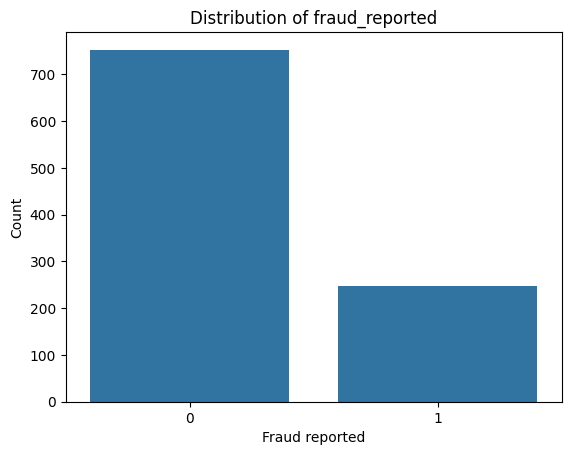

In [81]:
sns.countplot(data=df_clean,x="fraud_reported")
plt.title("Distribution of fraud_reported")
plt.xlabel("Fraud reported")
plt.ylabel("Count")
plt.savefig("./images/distribution of fraud_reported.png", dpi=300, bbox_inches="tight")
plt.show()

The target variable is imbalanced. Non-fraud cases appear more often than fraud cases.  
Because of this, accuracy alone may be misleading, so recall and F1-score for the fraud class are also important.

In [37]:
num_cols = df_clean.select_dtypes(include=['int64','float64']).columns

corr = df_clean[num_cols].corr()["fraud_reported"].abs().sort_values(ascending=False)
corr = corr.drop("fraud_reported")

corr

vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
policy_number                  0.029443
months_as_customer             0.020544
insured_zip                    0.019368
capital-gains                  0.019173
capital-loss                   0.014863
policy_deductable              0.014817
policy_annual_premium          0.014480
age                            0.012143
auto_year                      0.007928
incident_hour_of_the_day       0.004316
Name: fraud_reported, dtype: float64

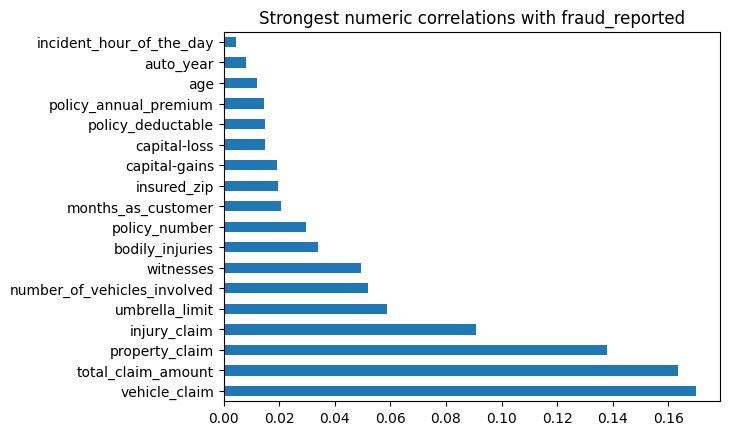

In [82]:
corr.plot(kind="barh",title = "Strongest numeric correlations with fraud_reported")
plt.savefig("./images/Strongest numeric correlations.png", dpi=300, bbox_inches="tight")
plt.show()

The numerical correlations with the target variable are relatively weak.  
This suggests that single numerical variables do not strongly separate fraud and non-fraud cases on their own.

In [43]:
cat_cols = df_clean.select_dtypes(include=["object"]).columns

cat_strength = {}

for col in cat_cols:
    fraud_rate = df_clean.groupby(col)["fraud_reported"].mean()
    cat_strength[col] = fraud_rate.max() - fraud_rate.min()


cat_strength = pd.Series(cat_strength).sort_values(ascending=False)
cat_strength.head(15)

policy_bind_date         1.000000
incident_location        1.000000
insured_hobbies          0.735178
incident_severity        0.538406
incident_date            0.529412
auto_model               0.381944
incident_state           0.255059
collision_type           0.221756
incident_type            0.205216
insured_occupation       0.199407
auto_make                0.174282
property_damage          0.090845
insured_relationship     0.087903
authorities_contacted    0.081912
incident_city            0.068162
dtype: float64

For categorical variables, fraud rate was calculated for each category.  
The difference between the highest and lowest fraud rate was used as a simple measure of how strongly a categorical feature may be related to fraud.

Some categorical variables, such as `policy_bind_date`, `incident_location`, and `incident_date`, received very high scores.  
However, these results should be interpreted carefully because these columns contain many unique values.

When a category appears only once or a few times, its fraud rate can easily be either 0 or 1.  
This creates an artificially high difference between the maximum and minimum fraud rate.

For this reason, these variables were not treated as the strongest meaningful predictors.  
More reliable categorical variables are those with repeated categories and clear differences in fraud rate, such as `insured_hobbies` and `incident_severity`.

In [46]:
df_clean[cat_cols].nunique().sort_values(ascending=False).head()

incident_location    1000
policy_bind_date      951
incident_date          60
auto_model             39
insured_hobbies        20
dtype: int64

The number of unique values confirms that `incident_location` is almost unique for every row, while `policy_bind_date` also has a very high number of unique categories.  
Because of this, these variables can produce misleadingly high fraud-rate differences and were removed before model training.

In [47]:
severity_fraud = (
    df_clean.groupby("incident_severity")["fraud_reported"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

severity_fraud

,count,mean
incident_severity,,
Major Damage,276,0.605072
Total Loss,280,0.128571
Minor Damage,354,0.107345
Trivial Damage,90,0.066667


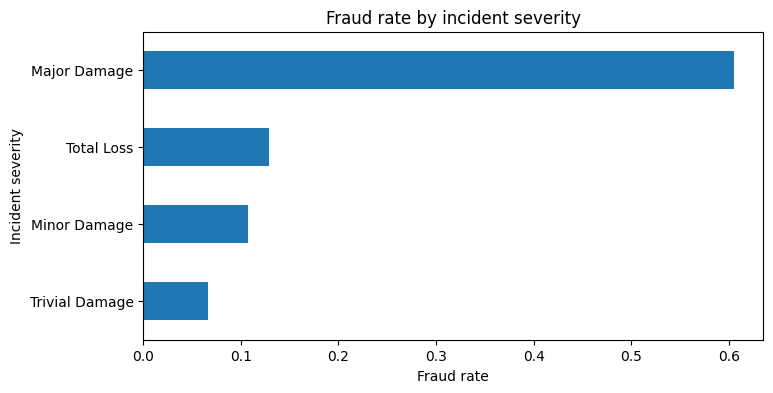

In [83]:
severity_fraud["mean"].sort_values().plot(
    kind="barh",
    figsize=(8, 4),
    title="Fraud rate by incident severity"
)

plt.xlabel("Fraud rate")
plt.ylabel("Incident severity")
plt.savefig("./images/fraud rate by incident severity.png", dpi=300, bbox_inches="tight")
plt.show()

In [49]:
hobby_fraud = (
    df_clean.groupby("insured_hobbies")["fraud_reported"]
    .agg(["count", "mean"])
    .sort_values("mean", ascending=False)
)

hobby_fraud

,count,mean
insured_hobbies,,
chess,46,0.826087
cross-fit,35,0.742857
yachting,53,0.301887
board-games,48,0.291667
polo,47,0.276596
reading,64,0.265625
base-jumping,49,0.265306
hiking,52,0.230769
paintball,57,0.228070


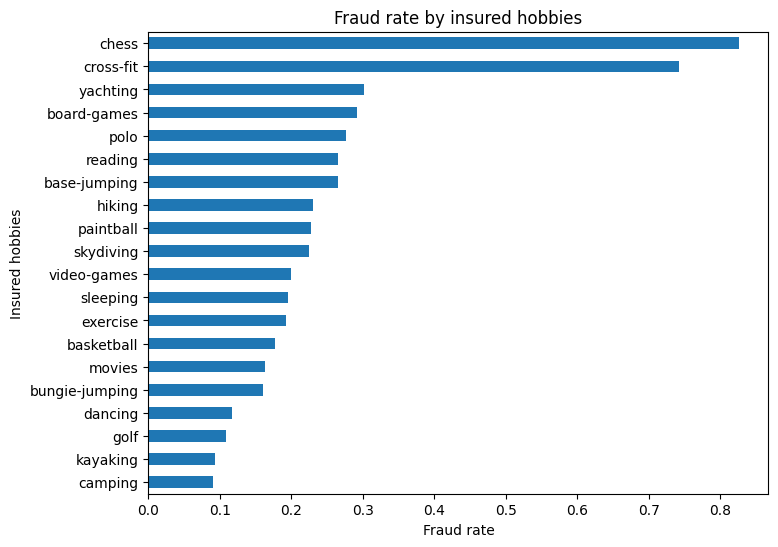

In [84]:
hobby_fraud["mean"].sort_values().plot(
    kind="barh",
    figsize=(8, 6),
    title="Fraud rate by insured hobbies"
)

plt.xlabel("Fraud rate")
plt.ylabel("Insured hobbies")
plt.savefig("./images/fraud rate by insured hobbies.png", dpi=300, bbox_inches="tight")
plt.show()

The `insured_hobbies` variable also shows strong differences in fraud rate.  
Some categories, especially `chess` and `cross-fit`, have a much higher fraud rate than the rest.

## 7. Data preprocessing
Before training the model, the dataset needs to be prepared for machine learning.  
Columns with very high uniqueness or low modeling value are removed, categorical variables are encoded using one-hot encoding, and the target variable is separated from the input features.

The final feature matrix is stored in `X`, while the target variable is stored in `y`.

In [85]:
df_model = df_clean.copy()

df_model = df_model.drop(columns=[
    "policy_number",
    "policy_bind_date",
    "incident_date",
    "incident_location"
])

X = df_model.drop(columns=["fraud_reported"])
y = df_model["fraud_reported"]

X = pd.get_dummies(X, drop_first=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 144)
y shape: (1000,)


After one-hot encoding, categorical variables are converted into numerical columns.  
This allows the Random Forest model to use both numerical and categorical information.

## 8. Model training
The dataset is split into training and testing sets.  
Stratified splitting is used to preserve the original proportion of fraud and non-fraud cases in both sets.

A Random Forest Classifier is used as the main model. Since the dataset is imbalanced, class weights are adjusted to make the model pay more attention to the fraud class.

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    random_state=42,
    class_weight={0: 1, 1: 4}
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Threshold tuning
By default, classification models usually use a threshold of `0.5` to assign predicted classes.  
However, in fraud detection, detecting fraudulent claims is more important than simply maximizing accuracy.

For this reason, several decision thresholds were tested.  
Lowering the threshold makes the model more likely to classify a claim as fraud, which usually increases recall for the fraud class but may also increase false positives.

In [72]:
y_proba = model.predict_proba(X_test)[:, 1]

for threshold in [0.5, 0.4, 0.35, 0.3, 0.25, 0.2]:
    y_pred_temp = (y_proba >= threshold).astype(int)
    
    print("\nThreshold:", threshold)
    print(confusion_matrix(y_test, y_pred_temp))
    print(classification_report(y_test, y_pred_temp))


Threshold: 0.5
[[141  10]
 [ 44   5]]
              precision    recall  f1-score   support

           0       0.76      0.93      0.84       151
           1       0.33      0.10      0.16        49

    accuracy                           0.73       200
   macro avg       0.55      0.52      0.50       200
weighted avg       0.66      0.73      0.67       200


Threshold: 0.4
[[132  19]
 [ 25  24]]
              precision    recall  f1-score   support

           0       0.84      0.87      0.86       151
           1       0.56      0.49      0.52        49

    accuracy                           0.78       200
   macro avg       0.70      0.68      0.69       200
weighted avg       0.77      0.78      0.77       200


Threshold: 0.35
[[129  22]
 [ 14  35]]
              precision    recall  f1-score   support

           0       0.90      0.85      0.88       151
           1       0.61      0.71      0.66        49

    accuracy                           0.82       200
   macro a

The threshold of `0.3` provided the best trade-off between fraud recall and precision.  
It detected most fraud cases while keeping the number of false alarms at a reasonable level.

## 10. Final model evaluation
Based on threshold tuning, the final decision threshold was set to `0.3`.  
The model is evaluated using accuracy, confusion matrix, precision, recall, and F1-score.

For this project, recall for the fraud class is especially important because missing a fraudulent claim may be more costly than generating a false alarm.

In [73]:
final_threshold = 0.3

y_pred = (y_proba >= final_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.825
[[127  24]
 [ 11  38]]
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       151
           1       0.61      0.78      0.68        49

    accuracy                           0.82       200
   macro avg       0.77      0.81      0.78       200
weighted avg       0.84      0.82      0.83       200



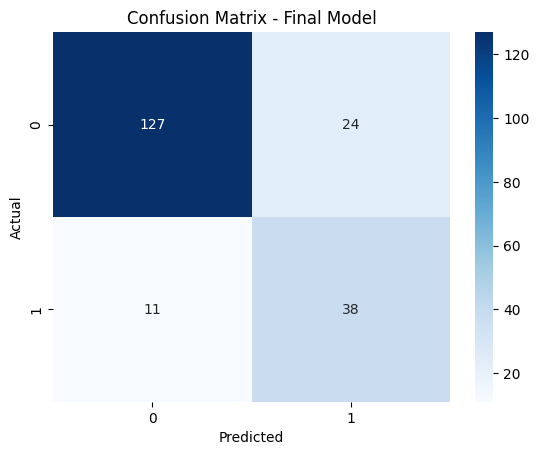

In [86]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("./images/confusion-matrix.png", dpi=300, bbox_inches="tight")
plt.show()

The final model detects a large part of fraud cases, while still maintaining acceptable precision.  
This is a better solution than the default threshold, which missed too many fraudulent claims.

## 11. Feature importance
Feature importance is used to understand which variables contributed the most to the Random Forest model predictions.  
This helps interpret the model and compare its behavior with the earlier exploratory data analysis.

In [76]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(20)

incident_severity_Minor Damage    0.072657
incident_severity_Total Loss      0.050013
insured_zip                       0.045088
property_claim                    0.043189
insured_hobbies_chess             0.040889
total_claim_amount                0.038724
vehicle_claim                     0.037976
injury_claim                      0.034085
policy_annual_premium             0.029949
months_as_customer                0.029077
age                               0.028762
insured_hobbies_cross-fit         0.027337
incident_hour_of_the_day          0.023715
auto_year                         0.023326
capital-gains                     0.020069
capital-loss                      0.017492
witnesses                         0.014591
collision_type_Unknown            0.009546
insured_hobbies_golf              0.008956
umbrella_limit                    0.008886
dtype: float64

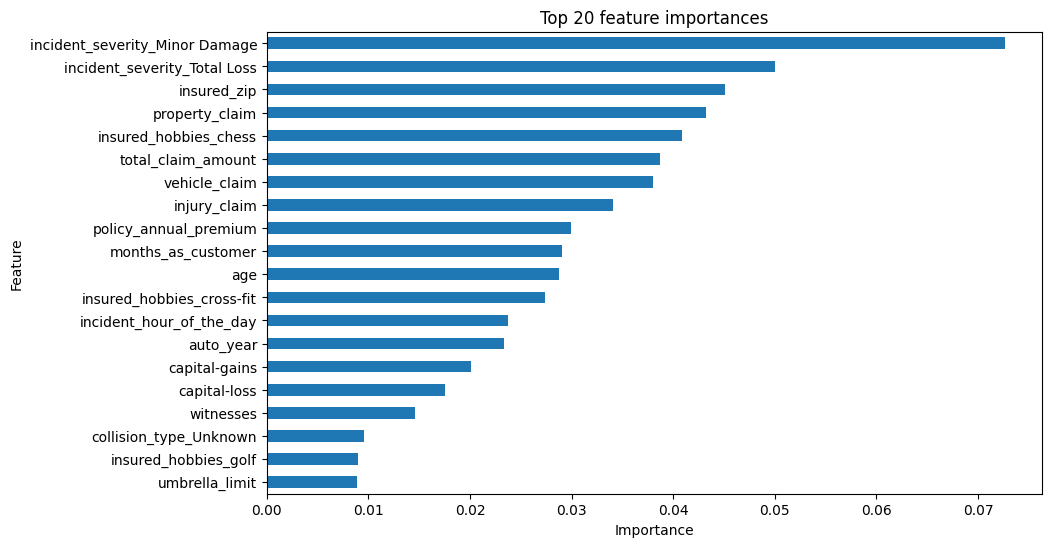

In [87]:
feature_importance.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    title="Top 20 feature importances"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.savefig("./images/top 20 feature importances.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Conclusions
The goal of this project was to build a machine learning model for detecting fraudulent insurance claims.

The dataset required cleaning, handling unknown values, encoding categorical variables, and addressing class imbalance.  
Exploratory data analysis showed that some variables, especially `incident_severity`, `insured_hobbies`, and claim amount features, were related to the probability of fraud.

A Random Forest Classifier was trained as the final model.  
Because fraud cases were less frequent than non-fraud cases, class weights were adjusted and the decision threshold was tuned.

The best final setup used:

- Random Forest Classifier
- class weights `{0: 1, 1: 4}`
- decision threshold `0.3`

This setup achieved a better balance between detecting fraud cases and limiting false alarms.  
The project also showed that accuracy alone is not enough for fraud detection. Recall, precision, F1-score, and the confusion matrix give a much better understanding of model performance.

### Final note

In a real business scenario, the final threshold should depend on the cost of false positives and false negatives.  
If missing fraud is very expensive, a lower threshold may be preferred. If false alarms are too costly, a higher threshold may be better.